# X-band Downlink Interference Analysis at Svalbard

This notebook demonstrates interference analysis between two constellations sharing
the X-band downlink spectrum, received at the Svalbard Satellite Station (SvalSat).

**Scenario**
- **Victim constellation**: 2 satellites at 700 km SSO, LTAN 10:30, -70 dBW/Hz PSD, isotropic TX
- **Interfering constellation**: 4 satellites at 550 km SSO, LTAN 11:00, -65 dBW/Hz PSD, isotropic TX
- **Victim receiver**: 5.4 m parabolic dish at Svalbard (78.229°N / 15.407°E)
- **Centre frequency**: 8200 MHz (X-band)
- **Interference threshold**: -237 dBW/Hz
- **Analysis window**: 90 days (2025-01-01 to 2025-04-01)

Interference events occur when an interfering satellite is visible to the Svalbard
antenna at the same time as a victim satellite, and the received interferer PSD
exceeds the threshold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

from missiontools import Spacecraft, GroundStation, IsotropicAntenna
from missiontools.comm import InterferenceAnalysis, SymmetricAntenna

## 1. Victim Constellation

Two spacecraft at 700 km in sun-synchronous orbit with a 10:30 LTAN.
The two satellites are separated by 180° in mean anomaly.

In [2]:
EPOCH = np.datetime64('2025-01-01T00:00:00', 'us')

vtx_ant_1 = IsotropicAntenna()
vtx_ant_2 = IsotropicAntenna()

vtx_sc_1 = Spacecraft.sunsync(
    altitude_km=700.0,
    node_solar_time='10:30',
    node_type='ascending',
    epoch=EPOCH,
    ma_deg=0.0,
)
vtx_sc_1.add_antenna(vtx_ant_1)

vtx_sc_2 = Spacecraft.sunsync(
    altitude_km=700.0,
    node_solar_time='10:30',
    node_type='ascending',
    epoch=EPOCH,
    ma_deg=180.0,
)
vtx_sc_2.add_antenna(vtx_ant_2)

print(f'Victim SC-1: alt={700} km, i={np.degrees(vtx_sc_1.i):.2f}°, period={2*np.pi*np.sqrt(vtx_sc_1.a**3/vtx_sc_1.central_body_mu)/60:.1f} min')
print(f'Victim SC-2: alt={700} km, i={np.degrees(vtx_sc_2.i):.2f}°, period={2*np.pi*np.sqrt(vtx_sc_2.a**3/vtx_sc_2.central_body_mu)/60:.1f} min')

Victim SC-1: alt=700 km, i=98.19°, period=98.8 min
Victim SC-2: alt=700 km, i=98.19°, period=98.8 min


## 2. Interfering Constellation

Four spacecraft at 550 km in sun-synchronous orbit with an 11:00 LTAN.
The satellites are evenly spaced at 0°, 90°, 180°, 270° in mean anomaly.

In [3]:
itx_ants = [IsotropicAntenna() for _ in range(4)]
itx_scs = []

for k in range(4):
    sc = Spacecraft.sunsync(
        altitude_km=550.0,
        node_solar_time='11:00',
        node_type='ascending',
        epoch=EPOCH,
        ma_deg=k * 90.0,
    )
    sc.add_antenna(itx_ants[k])
    itx_scs.append(sc)

print(f'Interfering constellation: {len(itx_scs)} satellites')
print(f'  alt=550 km, i={np.degrees(itx_scs[0].i):.2f}°, period={2*np.pi*np.sqrt(itx_scs[0].a**3/itx_scs[0].central_body_mu)/60:.1f} min')

Interfering constellation: 4 satellites
  alt=550 km, i=97.59°, period=95.6 min


## 3. Victim Receiver (Svalbard)

A 5.4 m parabolic dish antenna at SvalSat pointing at zenith.
The antenna pattern uses the parabolic envelope model at 8200 MHz.

In [4]:
svalbard = GroundStation(lat=78.229, lon=15.407, alt=500.0)

rx_dish = SymmetricAntenna.from_parabolic(
    diameter=5.4,
    frequency=8200e6,
    eff=0.6,
    envelope=True,
    azimuth_deg=0.0,
    elevation_deg=90.0,
)
svalbard.add_antenna(rx_dish)

print(f'Ground station : SvalSat ({svalbard.lat}°N, {svalbard.lon}°E, {svalbard.alt:.0f} m)')
print(f'Dish diameter  : 5.4 m')
print(f'Peak gain      : {rx_dish.peak_gain_dbi:.1f} dBi')

Ground station : SvalSat (78.229°N, 15.407°E, 500 m)
Dish diameter  : 5.4 m
Peak gain      : 51.1 dBi


## 4. Build Interference Analysis

Register all transmitters and receivers, then run the 90-day computation.
A `max_step` of 30 s is used for access interval detection, and an `event_step`
of 5 s for PSD sampling within candidate interference windows.

In [5]:
T_START = np.datetime64('2025-01-01T00:00:00', 'us')
T_END   = np.datetime64('2025-04-01T00:00:00', 'us')

PSD_THRESHOLD = -237.0  # dBW/Hz
F_MHZ = 8200.0         # MHz
VICTIM_TX_PSD = -70.0  # dBW/Hz
INTERFERER_TX_PSD = -65.0  # dBW/Hz

ia = InterferenceAnalysis(f_MHz=F_MHZ)

ia.add_victim_tx('VTX-1', vtx_ant_1, VICTIM_TX_PSD)
ia.add_victim_tx('VTX-2', vtx_ant_2, VICTIM_TX_PSD)

ia.add_victim_rx('Svalbard', rx_dish)

for k, ant in enumerate(itx_ants):
    ia.add_interfering_tx(f'ITX-{k+1}', ant, INTERFERER_TX_PSD)

print(f'Analysis period : {str(T_START)[:10]} to {str(T_END)[:10]} (90 days)')
print(f'Frequency       : {F_MHZ:.0f} MHz')
print(f'PSD threshold   : {PSD_THRESHOLD} dBW/Hz')
print(f'Victim TXs      : {len(ia._victim_txs)}')
print(f'Victim RXs      : {len(ia._victim_rxs)}')
print(f'Interfering TXs : {len(ia._interfering_txs)}')
print(f'Total triples   : {len(ia._victim_txs) * len(ia._victim_rxs) * len(ia._interfering_txs)}')

Analysis period : 2025-01-01 to 2025-04-01 (90 days)
Frequency       : 8200 MHz
PSD threshold   : -237.0 dBW/Hz
Victim TXs      : 2
Victim RXs      : 1
Interfering TXs : 4
Total triples   : 8


In [6]:
events = ia.compute(
    psd_threshold=PSD_THRESHOLD,
    start_time=T_START,
    end_time=T_END,
    max_step=30.0,
    event_step=5.0,
)

print(f'Interference events detected: {len(events)}')

Interference events detected: 118


## 5. Summary

In [7]:
total_interference_s = 0
for ev in events:
    dur = int((ev['end_time'] - ev['start_time']) / np.timedelta64(1, 's'))
    total_interference_s += dur

window_s = int((T_END - T_START) / np.timedelta64(1, 's'))

print('=' * 60)
print('  INTERFERENCE ANALYSIS SUMMARY')
print('=' * 60)
print(f'  Analysis period        : {str(T_START)[:10]} to {str(T_END)[:10]}')
print(f'  Duration               : {window_s / 86400:.0f} days')
print(f'  Centre frequency       : {F_MHZ:.0f} MHz')
print(f'  PSD threshold          : {PSD_THRESHOLD} dBW/Hz')
print(f'  ---')
print(f'  Total events           : {len(events)}')
print(f'  Total interference     : {total_interference_s:.0f} s '
      f'({total_interference_s / 3600:.2f} h)')
print(f'  Percentage of window   : {total_interference_s / window_s * 100:.4f}%')
if events:
    max_psd = max(ev['max_interferer_psd'] for ev in events)
    print(f'  Peak interferer PSD    : {max_psd:.1f} dBW/Hz')
    durs = [int((ev['end_time'] - ev['start_time']) / np.timedelta64(1, 's')) for ev in events]
    print(f'  Mean event duration    : {np.mean(durs):.0f} s ({np.mean(durs)/60:.1f} min)')
    print(f'  Max event duration     : {max(durs)} s ({max(durs)/60:.1f} min)')
    print(f'  Min event duration     : {min(durs)} s ({min(durs)/60:.1f} min)')
print('=' * 60)

  INTERFERENCE ANALYSIS SUMMARY
  Analysis period        : 2025-01-01 to 2025-04-01
  Duration               : 90 days
  Centre frequency       : 8200 MHz
  PSD threshold          : -237.0 dBW/Hz
  ---
  Total events           : 118
  Total interference     : 2971 s (0.83 h)
  Percentage of window   : 0.0382%
  Peak interferer PSD    : -192.7 dBW/Hz
  Mean event duration    : 25 s (0.4 min)
  Max event duration     : 35 s (0.6 min)
  Min event duration     : 0 s (0.0 min)


## 6. Events by Interfering Satellite

In [8]:
from collections import defaultdict

by_itx = defaultdict(list)
for ev in events:
    by_itx[ev['interfering_tx']].append(ev)

print(f"  {'Satellite':>12}  {'Events':>7}  {'Duration':>12}  {'Peak PSD':>10}")
print(f"  {'\u2500'*12}  {'\u2500'*7}  {'\u2500'*12}  {'\u2500'*10}")

for name in sorted(by_itx):
    evs = by_itx[name]
    dur = sum(int((e['end_time'] - e['start_time']) / np.timedelta64(1, 's')) for e in evs)
    peak = max(e['max_interferer_psd'] for e in evs)
    print(f'  {name:>12}  {len(evs):>7}  {dur // 60:>5d}m {dur % 60:02d}s  {peak:>9.1f} dBW/Hz')

print(f"  {'\u2500'*12}  {'\u2500'*7}  {'\u2500'*12}  {'\u2500'*10}")
total_dur = sum(int((e['end_time'] - e['start_time']) / np.timedelta64(1, 's')) for e in events)
overall_peak = max(e['max_interferer_psd'] for e in events) if events else float('nan')
print(f'  {"TOTAL":>12}  {len(events):>7}  {total_dur // 60:>5d}m {total_dur % 60:02d}s  {overall_peak:>9.1f} dBW/Hz')

     Satellite   Events      Duration    Peak PSD
  ────────────  ───────  ────────────  ──────────
         ITX-1       34     15m 10s     -192.7 dBW/Hz
         ITX-2       34     13m 47s     -193.7 dBW/Hz
         ITX-3       25     10m 20s     -200.0 dBW/Hz
         ITX-4       25     10m 14s     -195.8 dBW/Hz
  ────────────  ───────  ────────────  ──────────
         TOTAL      118     49m 31s     -192.7 dBW/Hz


## 7. Interference Event Timeline

Each bar represents one interference event, coloured by the interfering satellite.

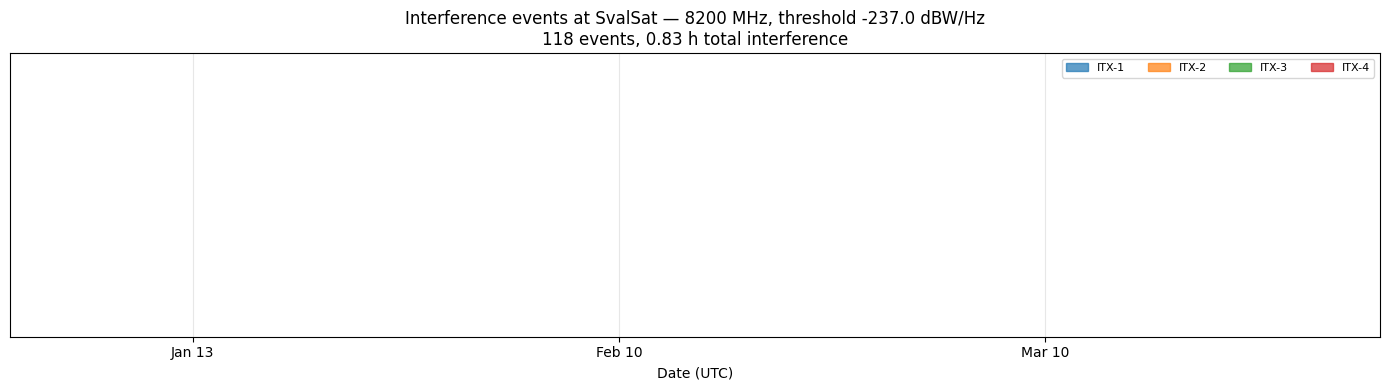

In [9]:
def to_dt(t64):
    return t64.astype('datetime64[ms]').astype(datetime)

itx_names_sorted = sorted(by_itx)
color_map = {name: f'C{k}' for k, name in enumerate(itx_names_sorted)}

fig, ax = plt.subplots(figsize=(14, 4))

for ev in events:
    ax.barh(
        0,
        left=to_dt(ev['start_time']),
        width=to_dt(ev['end_time']) - to_dt(ev['start_time']),
        height=0.5,
        color=color_map[ev['interfering_tx']],
        alpha=0.7,
    )

handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[n], alpha=0.7) for n in itx_names_sorted]
ax.legend(handles, itx_names_sorted, loc='upper right', ncol=len(itx_names_sorted), fontsize=8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=4))
ax.set_yticks([])
ax.set_xlim(to_dt(T_START), to_dt(T_END))
ax.set_xlabel('Date (UTC)')
ax.set_title(
    f'Interference events at SvalSat \u2014 {F_MHZ:.0f} MHz, '
    f'threshold {PSD_THRESHOLD} dBW/Hz\n'
    f'{len(events)} events, {total_interference_s/3600:.2f} h total interference'
)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Peak Interferer PSD Distribution

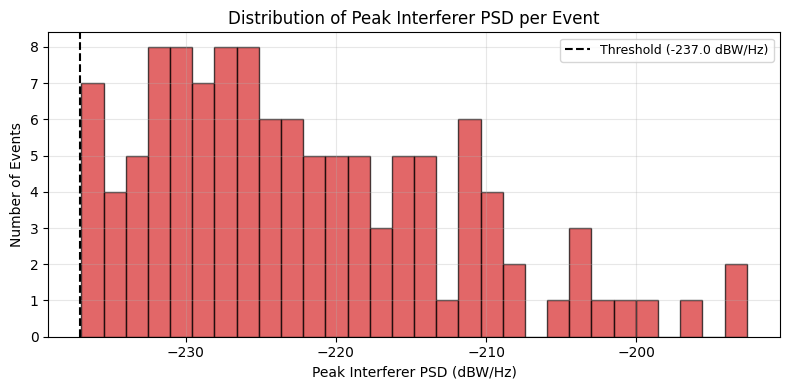

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

if events:
    peak_psds = [ev['max_interferer_psd'] for ev in events]
    ax.hist(peak_psds, bins=30, color='tab:red', alpha=0.7, edgecolor='black')
    ax.axvline(PSD_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold ({PSD_THRESHOLD} dBW/Hz)')
    ax.legend(fontsize=9)

ax.set_xlabel('Peak Interferer PSD (dBW/Hz)')
ax.set_ylabel('Number of Events')
ax.set_title('Distribution of Peak Interferer PSD per Event')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()